# Movies Data Analysis Project

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
#load datasets
df = pd.read_csv("movie_data.csv")
df.head()

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275


In [3]:
df.shape

(2000, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   title              2000 non-null   object 
 2   original_language  2000 non-null   object 
 3   overview           1985 non-null   object 
 4   release_date       1996 non-null   object 
 5   original_title     2000 non-null   object 
 6   vote_average       2000 non-null   float64
 7   vote_count         2000 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 125.1+ KB


In [5]:
df.isnull().sum()

id                    0
title                 0
original_language     0
overview             15
release_date          4
original_title        0
vote_average          0
vote_count            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(8)

# Data cleaning

In [7]:
# fix data type of date column
df['release_date'] = pd.to_datetime(df['release_date'],errors='coerce')
df['release_date'].dtype

dtype('<M8[ns]')

In [8]:
# fix null values
df['overview'] =df['overview'].fillna("No overview available")
# drop null dates rows
df = df.dropna(subset = ['release_date'])
df.isnull().sum()

id                   0
title                0
original_language    0
overview             0
release_date         0
original_title       0
vote_average         0
vote_count           0
dtype: int64

In [9]:
# remove duplicate values
df.drop_duplicates(inplace = True, keep = "first")
df.duplicated().sum()

np.int64(0)

# Exploratory data analysis (EDA)

In [10]:
# vote distribution 
vote = df['vote_average'].value_counts()
vote

vote_average
0.000    58
7.000    26
7.300    25
6.500    17
7.400    16
         ..
7.265     1
7.987     1
8.501     1
7.167     1
4.778     1
Name: count, Length: 1231, dtype: int64

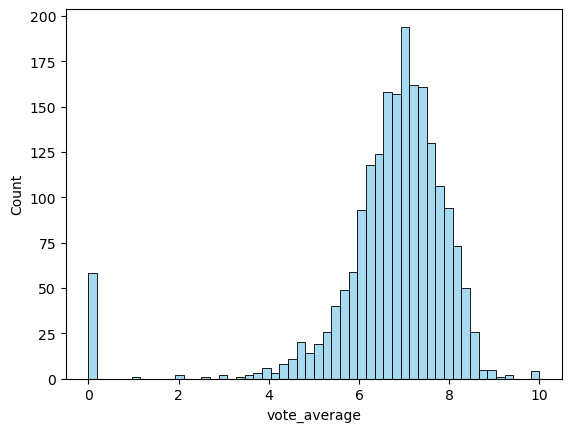

In [11]:
sns.histplot(data = df['vote_average'], color = 'skyblue')
plt.show()

In [12]:
# language breakdown
language = df['original_language'].value_counts().head()
language

original_language
en    1463
ja      79
ko      69
zh      50
fr      45
Name: count, dtype: int64

C:\Users\Sufiyan Ali\AppData\Local\Temp\ipykernel_10652\3360330762.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot (x = language.index , y = language.values, palette = "magma")


<Axes: xlabel='original_language'>

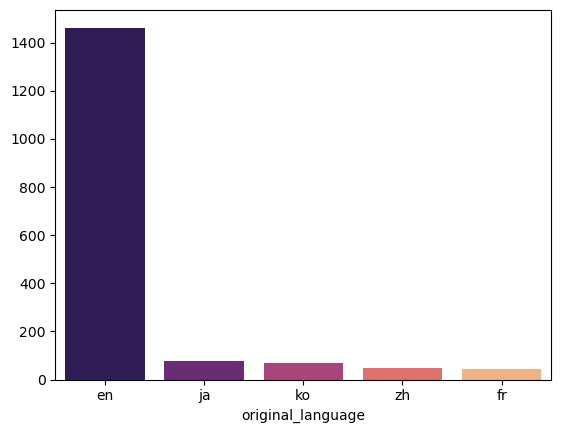

In [13]:
sns.barplot (x = language.index , y = language.values, palette = "magma")

In [14]:
# make year columns
df['year'] = df['release_date'].dt.year
df.head()

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count,year
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497,2026
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548,2026
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14,2026
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457,2026
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275,2026


In [15]:
# release trend over time
year = df['year'].value_counts().sort_index()
year

year
1938      2
1939      2
1940      2
1941      1
1943      1
       ... 
2024     96
2025    197
2026    233
2027      2
2028      1
Name: count, Length: 81, dtype: int64

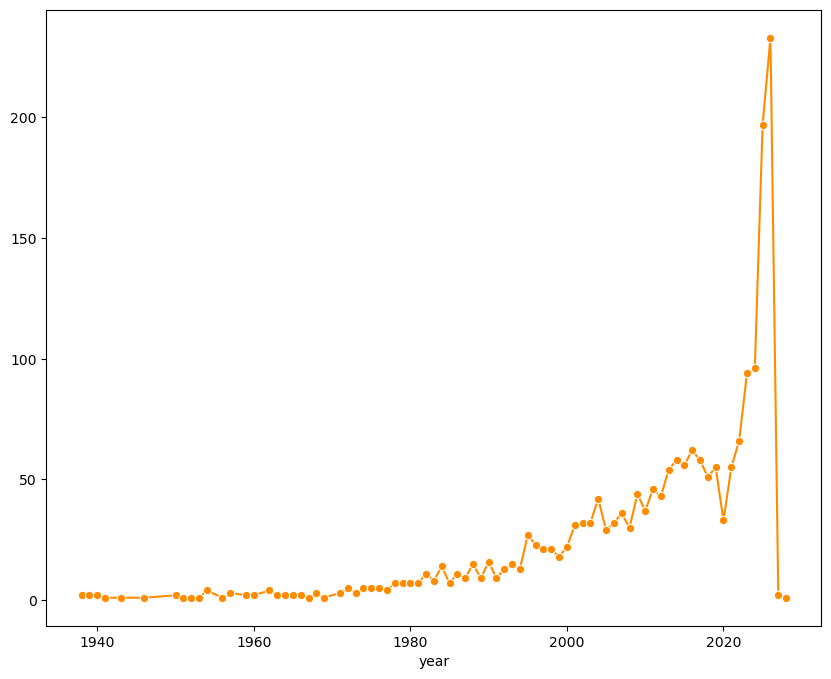

In [16]:
plt.figure(figsize=(10,8))
sns.lineplot(x = year.index , y = year.values , marker = 'o', color = 'darkorange')
plt.show()

In [17]:
df.groupby(df['vote_average'].round())['vote_count'].mean()

vote_average
0.0        0.000000
1.0        1.000000
2.0        1.666667
3.0        3.000000
4.0      318.137931
5.0      597.861111
6.0     2849.337931
7.0     5486.360234
8.0     8863.504310
9.0     6306.535714
10.0       1.000000
Name: vote_count, dtype: float64

<Axes: xlabel='vote_average', ylabel='vote_count'>

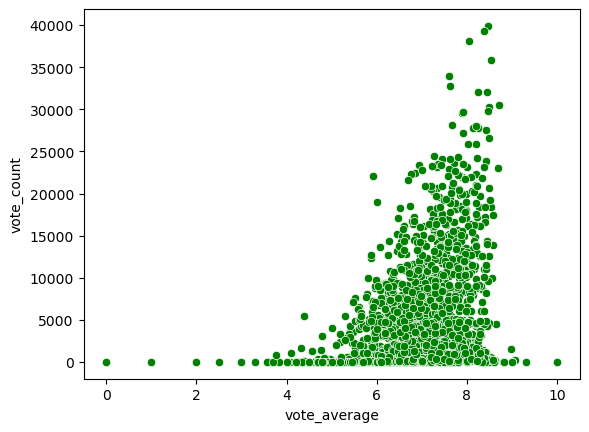

In [18]:
sns.scatterplot(data = df , x = 'vote_average', y = 'vote_count', color = 'green')

In [19]:
# engagement score
df['engagement_score'] = df['vote_average'] * np.log10(df['vote_count'])
df.head()

C:\Users\Sufiyan Ali\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,id,title,original_language,overview,release_date,original_title,vote_average,vote_count,year,engagement_score
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497,2026,21.301215
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548,2026,25.696795
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14,2026,6.647543
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457,2026,18.898705
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275,2026,16.343529


In [37]:
# best rated movies
top_10 = df[['title',"vote_count",'vote_average','engagement_score']].sort_values(by = 'engagement_score',ascending =False).head(10)
top_10

,title,vote_count,vote_average,engagement_score
50,The Shawshank Redemption,30472,8.721,39.104100
54,Interstellar,39900,8.476,38.997846
104,The Dark Knight,35827,8.531,38.851969
142,Inception,39304,8.372,38.464624
159,Fight Club,32074,8.438,38.022920
128,Pulp Fiction,30229,8.483,38.007435
106,The Godfather,22981,8.687,37.887212
163,Forrest Gump,29780,8.465,37.871773
111,The Lord of the Rings: The Return of the King,26581,8.499,37.604432
118,The Lord of the Rings: The Fellowship of the Ring,27587,8.434,37.452902


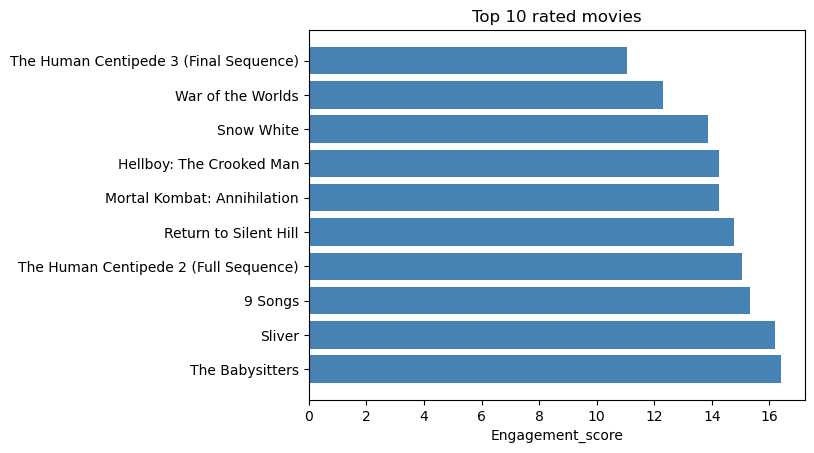

In [45]:
plt.barh(top_10['title'],top_10['engagement_score'],color = 'steelblue')
plt.title("Top 10 rated movies")
plt.xlabel("Engagement_score")
plt.gca().invert_yaxis()
plt.show()

In [46]:
# wrost rated movies
low_10 = df[df['vote_count']>500][['title',"vote_count",'vote_average','engagement_score']].sort_values(by = 'engagement_score',ascending =True).head(10)
low_10

,title,vote_count,vote_average,engagement_score
1351,The Human Centipede 3 (Final Sequence),852,3.776,11.065340
79,War of the Worlds,1002,4.105,12.318562
598,Snow White,1635,4.317,13.872756
1656,Hellboy: The Crooked Man,550,5.200,14.249886
335,Mortal Kombat: Annihilation,1345,4.557,14.257587
318,Return to Silent Hill,580,5.340,14.756705
937,The Human Centipede 2 (Full Sequence),1447,4.764,15.056472
136,9 Songs,580,5.546,15.325972
1607,Sliver,806,5.573,16.197005
155,The Babysitters,542,6.000,16.403996


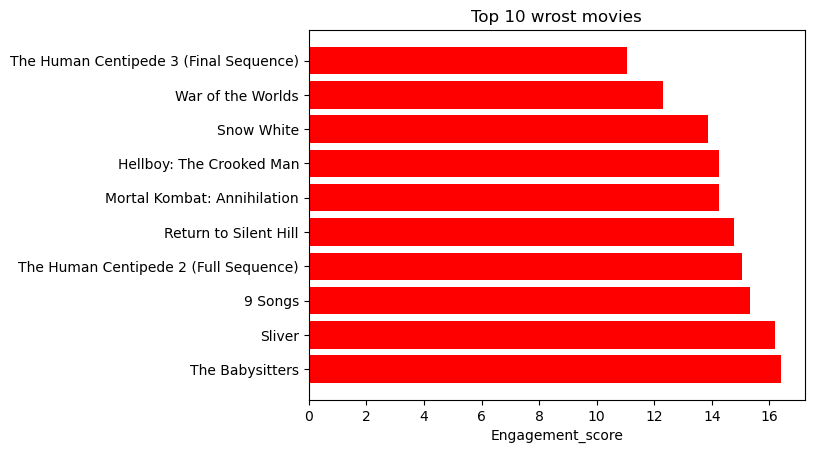

In [48]:
plt.barh(low_10['title'],low_10['engagement_score'],color = 'red')
plt.title("Top 10 wrost movies")
plt.xlabel("Engagement_score")
plt.gca().invert_yaxis()
plt.show()

# Conclusion
* 2,000 movies analyzed
* 8 columns — title, language, rating, votes, release date, overview
* Data range: 1938 to 2028
### What I Did:
* Loaded and explored data
* Rating Analysis
* Language breakdown
* Release Trend
* Built Engagement Score
* Top 10 movies
* wrost 10 movies
* Visualization

#### Key Learnings:
1. 1. Rating alone is misleading

* A movie with 9.8 score but only 3 votes cannot be trusted

2. Engagement Score is more reliable

* Combines both quality and popularity for a balanced result

3. Data filtering is essential

* Applying vote_count > 500 removed unreliable movies

4. Visualization beats raw numbers

* A bar chart communicates faster than a table ever could

This project analyzed 2,000 movies using Python and Pandas. We explored ratings, languages, and release trends. The key highlight was building an Engagement Score using vote_average × log10(vote_count) which gave us a more reliable ranking than raw ratings alone. By filtering movies with over 500 votes, we ensured our results were trustworthy. This analysis proves that popularity and quality together define a truly great movie.